In [1]:
import xarray as xr
import pandas as pd
from scipy.stats import linregress
import matplotlib.pyplot as plt

In [2]:
def classify_precip(row):
    code, year = row['WEATHER'], row['YEAR']
    if code == 5:
        return 'Non-Precipitation'
    elif code in [6, 7]:
        return 'Non-Precipitation' if year >= 2007 else 'Precipitation'
    else:
        return 'Precipitation'


In [3]:
def detrend_state(df):
    df = df.sort_values('DATE')
    x = df['DATE'].map(pd.Timestamp.toordinal)
    y = df['CRASH_COUNTS']
    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    df['DETRENDED_CRASH_COUNTS'] = y - (slope*x + intercept)
    return df


In [4]:
def read_psl_standard(filename, missing_value_marker=-999):
    """
    Read a NOAA PSL "standard format" time-series file into a pandas DataFrame.

    This function parses the PSL standard format:
      - First line contains start and end years
      - Each subsequent line has a year followed by 12 monthly values
      - A sentinel line with a missing-value marker (e.g., -999) follows the last year
      - Any additional lines (metadata/info) are ignored

    Returns
    -------
    df : pandas.DataFrame
        Wide format with columns: ['year', 'month_1', ..., 'month_12'].
    df_long : pandas.DataFrame
        Long format with columns: ['year', 'month', 'value'].

    Note
    ----
    This code was generated with the assistance of ChatGPT.
    """

    with open(filename, 'r') as f:
        # First line: contains the start and end year (not used directly, but can be checked)
        first_line = f.readline().strip().split()
        year_start, year_end = map(int, first_line)

        data_lines = []
        while True:
            line = f.readline()
            if not line:
                # Safety: file ended before sentinel found
                raise ValueError("Reached EOF before missing-value marker")
            parts = line.strip().split()
            # Stop when we reach the sentinel missing-value marker (e.g., -999)
            if len(parts) == 1 and parts[0] == str(missing_value_marker):
                break
            data_lines.append(parts)

        # Create DataFrame with year + 12 monthly values
        df = pd.DataFrame(data_lines, columns=['YEAR'] + [f'MONTH_{i}' for i in range(1, 13)])
        # Convert year to int and monthly values to float
        df = df.astype(float)
        df['YEAR'] = df['YEAR'].astype(int)

        # Reshape into long format for easier time-series analysis
        df_long = df.melt(id_vars='YEAR', var_name='MONTH', value_name='SST_VALUE')
        # Convert 'month' from "month_1" → integer 1
        df_long['MONTH'] = df_long['MONTH'].str.replace('MONTH_', '').astype(int)

        return df, df_long

In [5]:
state_dictAB = {
    1: 'AL', 2: 'AK', 4: 'AZ', 5: 'AR', 6: 'CA', 8: 'CO', 9: 'CT', 10: 'DE',
    11: 'DC', 12: 'FL', 13: 'GA', 15: 'HI', 16: 'ID', 17: 'IL', 18: 'IN',
    19: 'IA', 20: 'KS', 21: 'KY', 22: 'LA', 23: 'ME', 24: 'MD', 25: 'MA',
    26: 'MI', 27: 'MN', 28: 'MS', 29: 'MO', 30: 'MT', 31: 'NE', 32: 'NV',
    33: 'NH', 34: 'NJ', 35: 'NM', 36: 'NY', 37: 'NC', 38: 'ND', 39: 'OH',
    40: 'OK', 41: 'OR', 42: 'PA', 44: 'RI', 45: 'SC', 46: 'SD', 47: 'TN',
    48: 'TX', 49: 'UT', 50: 'VT', 51: 'VA', 53: 'WA', 54: 'WV', 55: 'WI',
    56: 'WY'
}

In [6]:
excluded_states = {'DC', 'AK', 'HI', 'PR', 'PRCP'}

# 1. Define FARS, NINO34, and PRECIP Data Files

In [7]:
fars_file='../data/FARS/old/DATABASE3.csv'
nino34_file='../data/ENSO/ENSOMONTHLY.txt'
precip_file='../data/precip/state_precip_chirps.csv'

# 2. Read in NINO34 and FARS data

In [8]:
df_nino34=pd.read_csv(nino34_file,skiprows=1, header=None)
df_fars=pd.read_csv(fars_file)

In [9]:
# map states
df_fars['STATE_ABBR'] = df_fars['STATE'].map(state_dictAB)

# Subset Years
df_fars = df_fars[(df_fars["YEAR"] >= 1981) & (df_fars["YEAR"] <= 2019)]

df_fars.head()

,STATE,COUNTY,CITY,MONTH,DAY,YEAR,HOUR,MINUTE,WEATHER,FATALS,DAY_WEEK,SST_value,STATE_ABBR
28953,1,73,0,1,6,1981,17,30,2,1,3,-0.36,AL
28954,1,15,100,1,21,1981,19,4,2,1,4,-0.36,AL
28955,1,17,0,1,20,1981,16,30,2,1,3,-0.36,AL
28956,1,77,0,1,20,1981,17,30,2,1,3,-0.36,AL
28957,2,20,130,1,25,1981,5,10,2,2,1,-0.36,AK


# 3. Convert NINO34 data from PSL standard format to YEAR, MONTH, SST_VALUE format

In [10]:
df_junk, df_nino34 = read_psl_standard(nino34_file,missing_value_marker=-99.99)
print(df_nino34)

     YEAR  MONTH  SST_VALUE
0    1948      1     -99.99
1    1949      1     -99.99
2    1950      1      -1.99
3    1951      1      -1.30
4    1952      1       0.13
..    ...    ...        ...
931  2021     12      -1.06
932  2022     12      -0.85
933  2023     12       2.03
934  2024     12      -0.60
935  2025     12     -99.99

[936 rows x 3 columns]


# 4. Merge the NINO34 and FARS DATA into a single database

In [12]:
merged_df = pd.merge(
    df_fars,
    df_nino34,
    left_on=["YEAR", "MONTH"],
    right_on=["YEAR", "MONTH"],
    how="left",
)

In [13]:
merged_df

,STATE,COUNTY,CITY,MONTH,DAY,YEAR,HOUR,MINUTE,WEATHER,FATALS,DAY_WEEK,SST_value,STATE_ABBR,SST_VALUE
0,1,73,0,1,6,1981,17,30,2,1,3,-0.36,AL,-0.36
1,1,15,100,1,21,1981,19,4,2,1,4,-0.36,AL,-0.36
2,1,17,0,1,20,1981,16,30,2,1,3,-0.36,AL,-0.36
3,1,77,0,1,20,1981,17,30,2,1,3,-0.36,AL,-0.36
4,2,20,130,1,25,1981,5,10,2,2,1,-0.36,AK,-0.36
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
165097,34,17,1520,12,11,2019,2,27,12,1,4,0.52,NJ,0.52
165098,42,21,8240,12,13,2019,9,48,12,1,6,0.52,PA,0.52
165099,42,83,0,12,2,2019,13,52,12,1,2,0.52,PA,0.52
165100,42,35,0,12,1,2019,11,26,12,1,1,0.52,PA,0.52


# 5. Read in State Precip Data 

In [14]:
df_state_precip=pd.read_csv(precip_file)

In [15]:
# Date handling
df_state_precip["DATE"] = pd.to_datetime(df_state_precip["DATE"])
df_state_precip["YEAR"] = df_state_precip["DATE"].dt.year
df_state_precip["MONTH"] = df_state_precip["DATE"].dt.month
df_state_precip["DAY"] = df_state_precip["DATE"].dt.day

# Remove excluded states
df_state_precip['STATE_ABBR'] = df_state_precip['STATE'].map(state_dictAB)
df_state_precip = df_state_precip.dropna(subset=['STATE_ABBR']).copy()
df_state_precip = df_state_precip[~df_state_precip['STATE_ABBR'].isin(excluded_states)]

In [16]:
df_state_precip

,DATE,ANOM_MEAN,ANOM_SUM,STATE,STATEFP,STATE_ABBR,YEAR,MONTH,DAY
0,1981-01-01,-4.391150,-917.750447,1,1,AL,1981,1,1
1,1981-01-02,-4.417280,-923.211495,1,1,AL,1981,1,2
2,1981-01-03,-4.426943,-925.231093,1,1,AL,1981,1,3
3,1981-01-04,-4.419716,-923.720710,1,1,AL,1981,1,4
4,1981-01-05,-4.411256,-921.952587,1,1,AL,1981,1,5
...,...,...,...,...,...,...,...,...,...
172426,2019-12-27,-0.507263,-227.253931,56,56,WY,2019,12,27
172427,2019-12-28,-0.266899,-119.570896,56,56,WY,2019,12,28
172428,2019-12-29,-0.526915,-236.057830,56,56,WY,2019,12,29
172429,2019-12-30,-0.526406,-235.829965,56,56,WY,2019,12,30


# 6. Merge State Precip Data

In [17]:
## --- Step A: Filter merged_df to years 1981-2019 ---
merged_df_filtered = merged_df[(merged_df["YEAR"] >= 1981) & (merged_df["YEAR"] <= 2019)]

# --- Step B: Aggregate precipitation to monthly per state ---
df_state_precip["DATE"] = pd.to_datetime(df_state_precip["DATE"])
df_state_precip["YEAR"] = df_state_precip["DATE"].dt.year
df_state_precip["MONTH"] = df_state_precip["DATE"].dt.month

df_state_precip_monthly = (
    df_state_precip
    .groupby(["STATE", "YEAR", "MONTH"], as_index=False)
    .agg({
        "ANOM_MEAN": "mean",
        "ANOM_SUM": "sum",
        "STATE_ABBR": "first"  # preserve abbreviation
    })
)

# Step C: Filter crash data to valid years
valid_years = df_state_precip_monthly["YEAR"].unique()
merged_df_filtered = merged_df[merged_df["YEAR"].isin(valid_years)]

# Step D: Keep only states present in both datasets
#common_states = set(merged_df_filtered["STATE"].unique()) & set(df_state_precip_monthly["STATE"].unique())
#merged_df_filtered = merged_df_filtered[merged_df_filtered["STATE"].isin(common_states)]
#df_state_precip_monthly_filtered = df_state_precip_monthly[df_state_precip_monthly["STATE"].isin(common_states)]
df_state_precip_monthly_filtered=df_state_precip_monthly

# Step E: Merge
merged_df_filtered = merged_df_filtered.drop(columns=['STATE_ABBR'])

combined = pd.merge(
    merged_df_filtered,
    df_state_precip_monthly_filtered,
    on=['STATE','YEAR','MONTH'],
    how='left'
)

# Step F: Rename Columns
combined = combined.rename(columns={
    "ANOM_MEAN": "PRECIP_ANOM_MEAN",
    "ANOM_SUM": "PRECIP_ANOM_SUM"
})

# Step G: Drop unnecessary columns
combined = combined.drop(columns=[ "DAY","HOUR", "MINUTE", "DAY_WEEK"])

# Step H: Reorder columns
cols = ["STATE", "STATE_ABBR", "YEAR", "MONTH", "COUNTY", "CITY",
        "WEATHER", "FATALS", "SST_VALUE", "PRECIP_ANOM_MEAN", "PRECIP_ANOM_SUM"]
combined = combined[cols]

In [18]:
combined

,STATE,STATE_ABBR,YEAR,MONTH,COUNTY,CITY,WEATHER,FATALS,SST_VALUE,PRECIP_ANOM_MEAN,PRECIP_ANOM_SUM
0,1,AL,1981,1,73,0,2,1,-0.36,-2.909368,-18849.793647
1,1,AL,1981,1,15,100,2,1,-0.36,-2.909368,-18849.793647
2,1,AL,1981,1,17,0,2,1,-0.36,-2.909368,-18849.793647
3,1,AL,1981,1,77,0,2,1,-0.36,-2.909368,-18849.793647
4,2,NaN,1981,1,20,130,2,2,-0.36,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
165097,34,NJ,2019,12,17,1520,12,1,0.52,1.136921,1163.069748
165098,42,PA,2019,12,21,8240,12,1,0.52,0.232959,1437.123972
165099,42,PA,2019,12,83,0,12,1,0.52,0.232959,1437.123972
165100,42,PA,2019,12,35,0,12,1,0.52,0.232959,1437.123972


# 6b. Classify Precip or non-Precip weather-type

In [19]:
combined.loc[:, 'WEATHER_TYPE'] = combined.apply(classify_precip, axis=1)

In [20]:
combined

,STATE,STATE_ABBR,YEAR,MONTH,COUNTY,CITY,WEATHER,FATALS,SST_VALUE,PRECIP_ANOM_MEAN,PRECIP_ANOM_SUM,WEATHER_TYPE
0,1,AL,1981,1,73,0,2,1,-0.36,-2.909368,-18849.793647,Precipitation
1,1,AL,1981,1,15,100,2,1,-0.36,-2.909368,-18849.793647,Precipitation
2,1,AL,1981,1,17,0,2,1,-0.36,-2.909368,-18849.793647,Precipitation
3,1,AL,1981,1,77,0,2,1,-0.36,-2.909368,-18849.793647,Precipitation
4,2,NaN,1981,1,20,130,2,2,-0.36,NaN,NaN,Precipitation
...,...,...,...,...,...,...,...,...,...,...,...,...
165097,34,NJ,2019,12,17,1520,12,1,0.52,1.136921,1163.069748,Precipitation
165098,42,PA,2019,12,21,8240,12,1,0.52,0.232959,1437.123972,Precipitation
165099,42,PA,2019,12,83,0,12,1,0.52,0.232959,1437.123972,Precipitation
165100,42,PA,2019,12,35,0,12,1,0.52,0.232959,1437.123972,Precipitation


# 6c. Select only Precip-related crashes prior to monthly summary

In [21]:
combined = combined[(combined["WEATHER_TYPE"] == 'Precipitation')]

In [22]:
combined

,STATE,STATE_ABBR,YEAR,MONTH,COUNTY,CITY,WEATHER,FATALS,SST_VALUE,PRECIP_ANOM_MEAN,PRECIP_ANOM_SUM,WEATHER_TYPE
0,1,AL,1981,1,73,0,2,1,-0.36,-2.909368,-18849.793647,Precipitation
1,1,AL,1981,1,15,100,2,1,-0.36,-2.909368,-18849.793647,Precipitation
2,1,AL,1981,1,17,0,2,1,-0.36,-2.909368,-18849.793647,Precipitation
3,1,AL,1981,1,77,0,2,1,-0.36,-2.909368,-18849.793647,Precipitation
4,2,NaN,1981,1,20,130,2,2,-0.36,NaN,NaN,Precipitation
...,...,...,...,...,...,...,...,...,...,...,...,...
165097,34,NJ,2019,12,17,1520,12,1,0.52,1.136921,1163.069748,Precipitation
165098,42,PA,2019,12,21,8240,12,1,0.52,0.232959,1437.123972,Precipitation
165099,42,PA,2019,12,83,0,12,1,0.52,0.232959,1437.123972,Precipitation
165100,42,PA,2019,12,35,0,12,1,0.52,0.232959,1437.123972,Precipitation


# 7. Write Database to File

In [23]:
outFile='../data/combined_databases/database_fars_nino34_precip_monthly.csv'
combined.to_csv(outFile)

# 8. Make Monthly Summary by State Database

In [24]:
# 1️⃣ Aggregate monthly totals per state (crashes + precipitation anomalies + SST)
monthly_state = combined.groupby(['STATE_ABBR','YEAR','MONTH'], as_index=False).agg({
    'FATALS':'sum',             # monthly crash counts
    'PRECIP_ANOM_MEAN':'mean',  # monthly mean precipitation anomaly per state
    'PRECIP_ANOM_SUM':'sum',    # monthly sum of precipitation anomalies per state
    'SST_VALUE':'mean'          # average NINO3.4 SST anomaly
})
monthly_state.head()

# Rename columns
monthly_state.rename(columns={
    'FATALS':'CRASH_COUNTS',
    'SST_VALUE':'NINO34_SST_ANOM'
}, inplace=True)

# Create DATE column
monthly_state['DATE'] = pd.to_datetime(monthly_state[['YEAR','MONTH']].assign(DAY=1))

# 2️⃣ Compute seasonal anomaly per state
monthly_state['ANOM_CRASH_COUNTS'] = monthly_state['CRASH_COUNTS'] - \
    monthly_state.groupby(['STATE_ABBR','MONTH'])['CRASH_COUNTS'].transform('mean')

# 3️⃣ Detrend crash counts per state
monthly_state = monthly_state.groupby('STATE_ABBR').apply(detrend_state).reset_index(drop=True)

monthly_state.head()

# 4️⃣ Compute national-level monthly totals
monthly_national = monthly_state.groupby(['YEAR','MONTH'], as_index=False).agg({
    'CRASH_COUNTS':'sum',                     # sum over states
    'ANOM_CRASH_COUNTS':'sum',                # sum over states
    'DETRENDED_CRASH_COUNTS':'sum',           # sum over states
    'PRECIP_ANOM_MEAN':'mean',                # average over states
    'PRECIP_ANOM_SUM':'sum',                  # sum over states
    'NINO34_SST_ANOM':'mean'                  # average over states
})

monthly_national['STATE_ABBR'] = 'USA'
monthly_national['DATE'] = pd.to_datetime(monthly_national[['YEAR','MONTH']].assign(DAY=1))

# 5️⃣ Combine state-level and national-level data
monthly_summary = pd.concat([monthly_state, monthly_national], ignore_index=True)

# 6️⃣ Final column order
monthly_summary = monthly_summary[[
    'STATE_ABBR','YEAR','MONTH','CRASH_COUNTS','ANOM_CRASH_COUNTS','DETRENDED_CRASH_COUNTS',
    'PRECIP_ANOM_MEAN','PRECIP_ANOM_SUM','NINO34_SST_ANOM'
]]

monthly_summary.head()


/tmp/ipykernel_1045548/2897546027.py:24: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  monthly_state = monthly_state.groupby('STATE_ABBR').apply(detrend_state).reset_index(drop=True)


,STATE_ABBR,YEAR,MONTH,CRASH_COUNTS,ANOM_CRASH_COUNTS,DETRENDED_CRASH_COUNTS,PRECIP_ANOM_MEAN,PRECIP_ANOM_SUM,NINO34_SST_ANOM
0,AL,1981,1,4,-8.102564,-7.500721,-2.909368,-75399.174587,-0.36
1,AL,1981,2,6,-4.512821,-5.502426,0.921696,32362.587778,-0.64
2,AL,1981,12,10,-3.051282,-1.519082,0.591149,30640.421086,-0.20
3,AL,1982,1,7,-5.102564,-4.520786,0.599387,23300.557964,0.13
4,AL,1982,2,6,-4.512821,-5.522490,1.879957,55007.549538,-0.17


# 9. Write Monthly Summary Data

In [25]:
outFile='../data/combined_databases/database_fars_nino34_precip_monthly_summary_state.csv'
monthly_summary.to_csv(outFile)

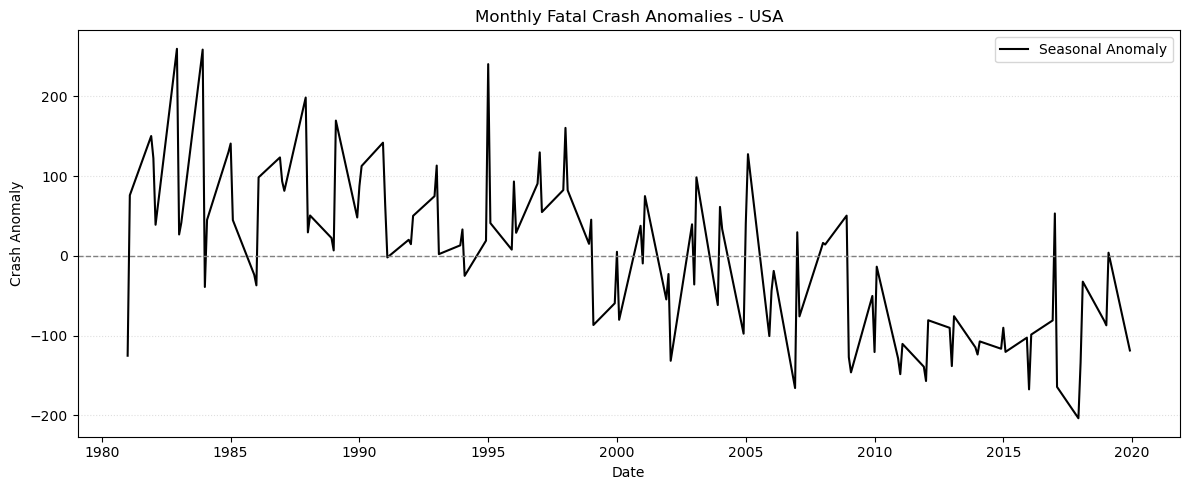

In [26]:
monthly_summary['DATE'] = pd.to_datetime(monthly_summary[['YEAR','MONTH']].assign(DAY=1))
# Select USA data
usa = monthly_summary[monthly_summary['STATE_ABBR'] == 'USA'].sort_values('DATE')

plt.figure(figsize=(12,5))
plt.plot(usa['DATE'], usa['ANOM_CRASH_COUNTS'], color='black', lw=1.5, label='Seasonal Anomaly')
plt.axhline(0, color='gray', lw=1, linestyle='--')
plt.xlabel('Date')
plt.ylabel('Crash Anomaly')
plt.title('Monthly Fatal Crash Anomalies - USA')
plt.grid(axis='y', linestyle=':', alpha=0.4)
plt.legend()
plt.tight_layout()
plt.show()

In [27]:
import pandas as pd
from scipy.stats import linregress

# 1️⃣ Aggregate monthly totals nationwide
monthly_national = (
    df_fars.groupby(['YEAR','MONTH'], as_index=False)
    .agg({'FATALS':'sum'})
)
monthly_national.rename(columns={'FATALS':'CRASH_COUNTS'}, inplace=True)

# 2️⃣ Create DATE column (first day of the month)
monthly_national['DATE'] = pd.to_datetime(
    monthly_national[['YEAR','MONTH']].assign(DAY=1)
)

# 3️⃣ Compute seasonal anomaly (monthly anomaly for national totals)
monthly_national['ANOM_CRASH_COUNTS'] = monthly_national['CRASH_COUNTS'] - \
    monthly_national.groupby('MONTH')['CRASH_COUNTS'].transform('mean')

# 4️⃣ Detrend national crash counts
x = monthly_national['DATE'].map(pd.Timestamp.toordinal)
y = monthly_national['CRASH_COUNTS']
slope, intercept, r_value, p_value, std_err = linregress(x, y)
monthly_national['DETRENDED_CRASH_COUNTS'] = y - (slope*x + intercept)

# 5️⃣ Add a pseudo-state column for convenience
monthly_national['STATE_ABBR'] = 'USA'

# 6️⃣ Reorder columns
monthly_national = monthly_national[[
    'STATE_ABBR','YEAR','MONTH','CRASH_COUNTS','ANOM_CRASH_COUNTS','DETRENDED_CRASH_COUNTS','DATE'
]]

monthly_national.head()


,STATE_ABBR,YEAR,MONTH,CRASH_COUNTS,ANOM_CRASH_COUNTS,DETRENDED_CRASH_COUNTS,DATE
0,USA,1981,1,430,-114.666667,-90.859180,1981-01-01
1,USA,1981,2,607,154.717949,86.683370,1981-02-01
2,USA,1981,3,392,-30.435897,-127.826585,1981-03-01
3,USA,1981,4,394,55.076923,-125.284036,1981-04-01
4,USA,1981,5,418,114.538462,-100.758987,1981-05-01


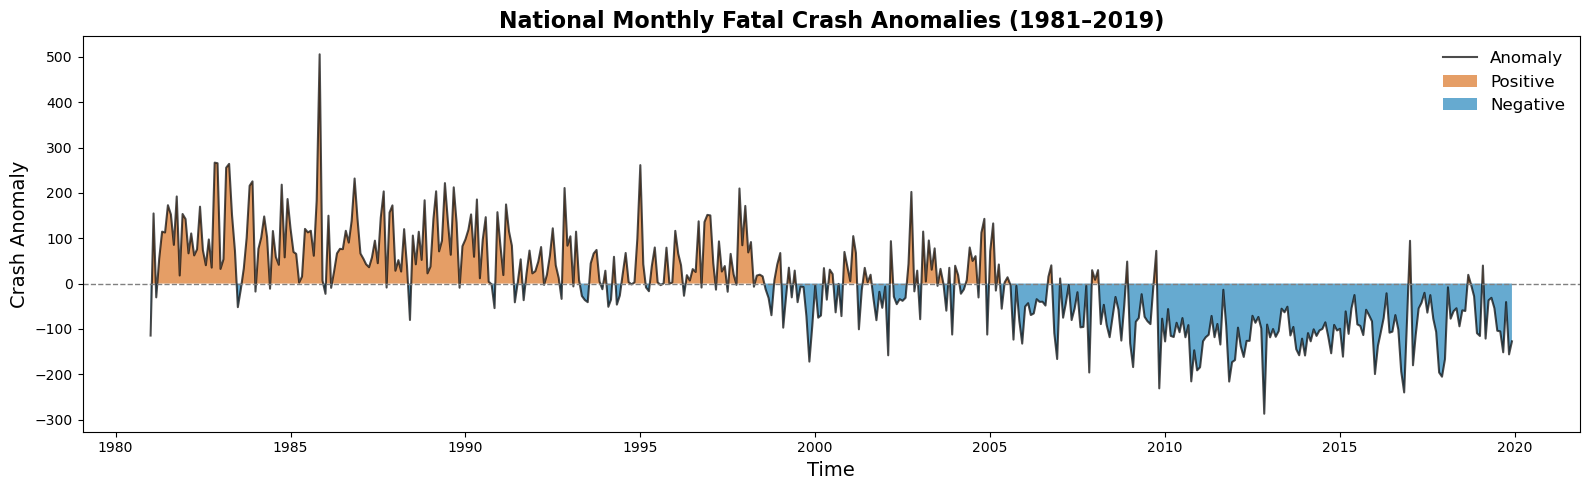

In [28]:
import matplotlib.pyplot as plt

# Select only national data
df = monthly_national.copy()

fig, ax = plt.subplots(figsize=(16,5))
ax.plot(df['DATE'], df['ANOM_CRASH_COUNTS'], color='black', linewidth=1.5, alpha=0.7, label='Anomaly')

# Highlight positive vs negative
ax.fill_between(df['DATE'], 0, df['ANOM_CRASH_COUNTS'],
                where=df['ANOM_CRASH_COUNTS']>=0,
                facecolor='#D55E00', alpha=0.6, interpolate=True, label='Positive')
ax.fill_between(df['DATE'], 0, df['ANOM_CRASH_COUNTS'],
                where=df['ANOM_CRASH_COUNTS']<0,
                facecolor='#0072B2', alpha=0.6, interpolate=True, label='Negative')

ax.axhline(0, color='gray', linestyle='--', linewidth=1)

ax.set_title('National Monthly Fatal Crash Anomalies (1981–2019)', fontsize=16, fontweight='bold')
ax.set_ylabel('Crash Anomaly', fontsize=14)
ax.set_xlabel('Time', fontsize=14)
ax.legend(fontsize=12, frameon=False)

plt.tight_layout()
plt.show()


/tmp/ipykernel_1045548/3909721063.py:24: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  monthly_state = monthly_state.groupby('STATE_ABBR').apply(detrend_state).reset_index(drop=True)


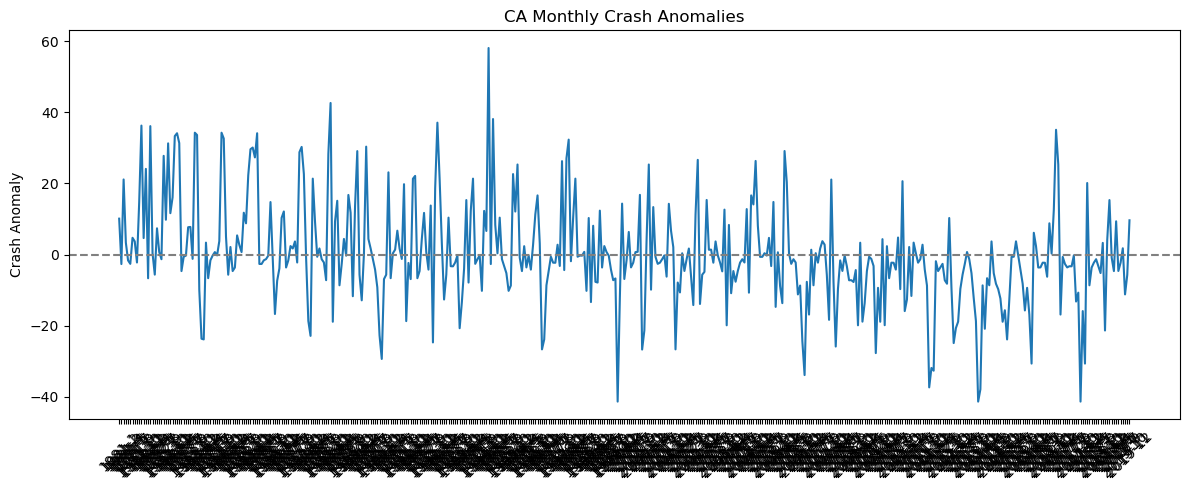

In [29]:
import pandas as pd
from scipy.stats import linregress
import matplotlib.pyplot as plt

# 1️⃣ Aggregate monthly totals per state
monthly_state = df_fars.groupby(['STATE_ABBR','YEAR','MONTH'], as_index=False).agg({
    'FATALS':'sum'  # monthly crash counts
})
monthly_state.rename(columns={'FATALS':'CRASH_COUNTS'}, inplace=True)

# 2️⃣ Compute state-level seasonal mean and anomaly
monthly_state['STATE_MONTH_MEAN'] = monthly_state.groupby(['STATE_ABBR','MONTH'])['CRASH_COUNTS'].transform('mean')
monthly_state['ANOM_CRASH_COUNTS'] = monthly_state['CRASH_COUNTS'] - monthly_state['STATE_MONTH_MEAN']

# 3️⃣ Detrend per state
def detrend_state(df):
    df = df.sort_values(['YEAR','MONTH'])
    x = pd.to_datetime(df[['YEAR','MONTH']].assign(DAY=1)).map(pd.Timestamp.toordinal)
    y = df['CRASH_COUNTS']
    slope, intercept, r_value, p_value, std_err = linregress(x, y)
    df['DETRENDED_CRASH_COUNTS'] = y - (slope*x + intercept)
    return df

monthly_state = monthly_state.groupby('STATE_ABBR').apply(detrend_state).reset_index(drop=True)

# 4️⃣ Compute national totals (sum of state anomalies)
monthly_national = monthly_state.groupby(['YEAR','MONTH'], as_index=False).agg({
    'CRASH_COUNTS':'sum',
    'ANOM_CRASH_COUNTS':'sum',
    'DETRENDED_CRASH_COUNTS':'sum'
})
monthly_national['STATE_ABBR'] = 'USA'

# 5️⃣ Optional: Compute state mean (for plotting)
state_means = monthly_state.groupby('STATE_ABBR')['CRASH_COUNTS'].mean().sort_values()

# 6️⃣ Plot example for a single state
state_to_plot = 'CA'
df_plot = monthly_state[monthly_state['STATE_ABBR']==state_to_plot]

plt.figure(figsize=(12,5))
plt.plot(df_plot['YEAR'].astype(str) + '-' + df_plot['MONTH'].astype(str), df_plot['ANOM_CRASH_COUNTS'], label='Seasonal Anomaly')
plt.axhline(0, color='gray', linestyle='--')
plt.title(f'{state_to_plot} Monthly Crash Anomalies')
plt.ylabel('Crash Anomaly')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


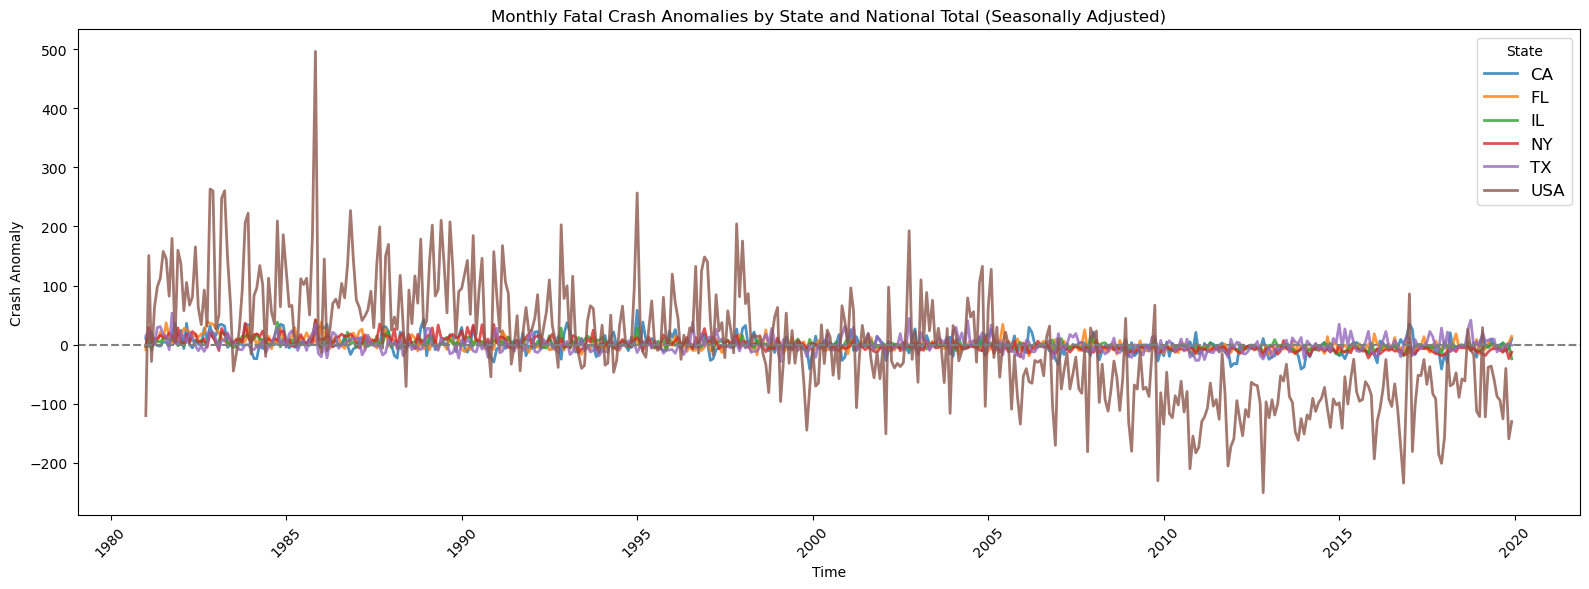

In [30]:
import matplotlib.pyplot as plt

# Select states to plot
states_to_plot = ['CA', 'TX', 'FL', 'NY', 'IL']  # example top 5 states
df_states_plot = monthly_state[monthly_state['STATE_ABBR'].isin(states_to_plot)]

# Add national total
monthly_national['LABEL'] = 'USA'
df_plot = pd.concat([df_states_plot, monthly_national], ignore_index=True)

# Create a date column for plotting
df_plot['DATE'] = pd.to_datetime(df_plot[['YEAR','MONTH']].assign(DAY=1))

# Plot
plt.figure(figsize=(16,6))
for state in df_plot['STATE_ABBR'].unique():
    df_s = df_plot[df_plot['STATE_ABBR']==state]
    plt.plot(df_s['DATE'], df_s['ANOM_CRASH_COUNTS'], label=state, linewidth=2, alpha=0.8)

plt.axhline(0, color='gray', linestyle='--', linewidth=1.5)
plt.title('Monthly Fatal Crash Anomalies by State and National Total (Seasonally Adjusted)')
plt.ylabel('Crash Anomaly')
plt.xlabel('Time')
plt.xticks(rotation=45)
plt.legend(title='State', fontsize=12)
plt.tight_layout()
plt.show()

/tmp/ipykernel_1045548/799585444.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_states_plot['DATE'] = pd.to_datetime(df_states_plot[['YEAR','MONTH']].assign(DAY=1))


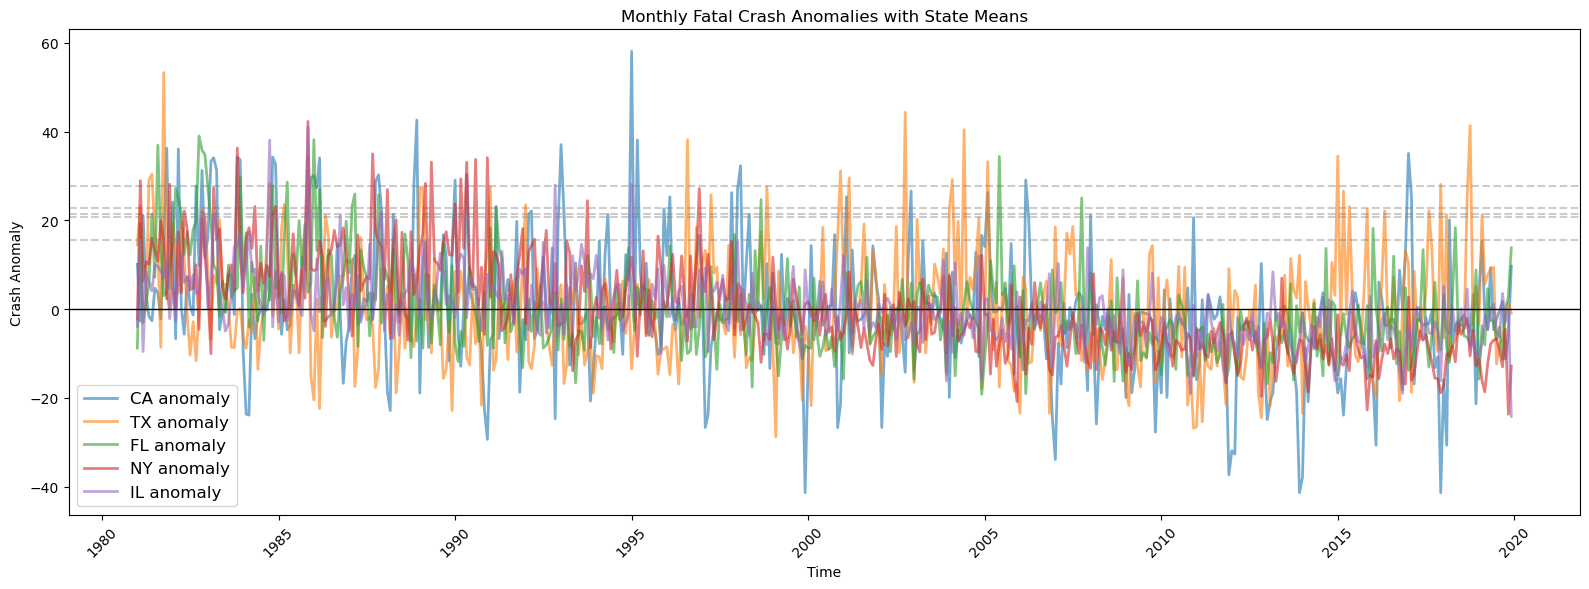

In [31]:
import matplotlib.pyplot as plt

# Choose states to plot
states_to_plot = ['CA', 'TX', 'FL', 'NY', 'IL']  # example

# Prepare data
df_states_plot = monthly_state[monthly_state['STATE_ABBR'].isin(states_to_plot)]
df_states_plot['DATE'] = pd.to_datetime(df_states_plot[['YEAR','MONTH']].assign(DAY=1))

# Plot
plt.figure(figsize=(16,6))

for state in states_to_plot:
    df_s = df_states_plot[df_states_plot['STATE_ABBR']==state]
    
    # Plot seasonal anomaly
    plt.plot(df_s['DATE'], df_s['ANOM_CRASH_COUNTS'], 
             label=f"{state} anomaly", linewidth=2, alpha=0.6)
    
    # Plot state mean as background line
    state_mean = df_s['CRASH_COUNTS'].mean()
    plt.axhline(state_mean, color='gray', linestyle='--', alpha=0.4)
    
plt.axhline(0, color='black', linestyle='-', linewidth=1)
plt.title('Monthly Fatal Crash Anomalies with State Means')
plt.ylabel('Crash Anomaly')
plt.xlabel('Time')
plt.xticks(rotation=45)
plt.legend(fontsize=12)
plt.tight_layout()
plt.show()


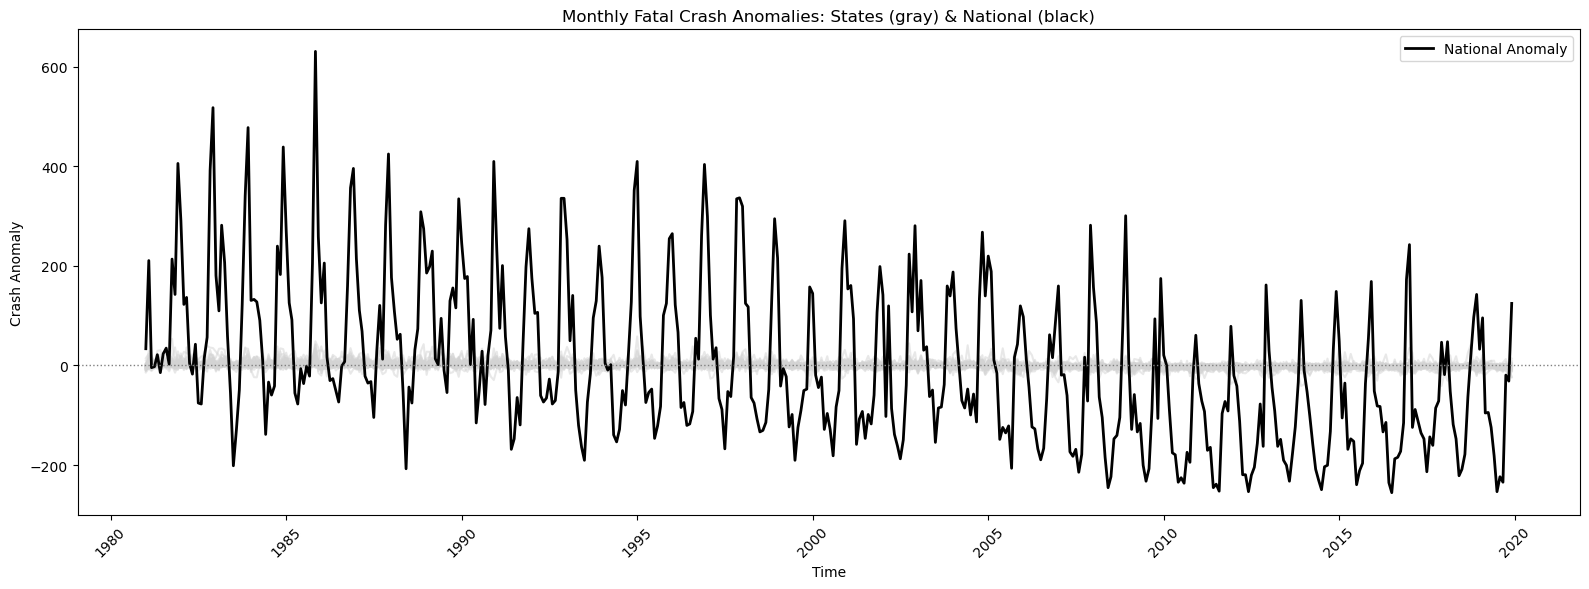

In [32]:
import matplotlib.pyplot as plt

# Prepare state anomalies
df_states_plot = monthly_state.copy()
df_states_plot['DATE'] = pd.to_datetime(df_states_plot[['YEAR','MONTH']].assign(DAY=1))

# Prepare national anomalies
monthly_national['DATE'] = pd.to_datetime(monthly_national[['YEAR','MONTH']].assign(DAY=1))
monthly_national['ANOM_CRASH_COUNTS'] = monthly_national['CRASH_COUNTS'] - monthly_national['CRASH_COUNTS'].mean()

plt.figure(figsize=(16,6))

# Plot state anomalies (light gray)
for state in df_states_plot['STATE_ABBR'].unique():
    df_s = df_states_plot[df_states_plot['STATE_ABBR']==state]
    plt.plot(df_s['DATE'], df_s['ANOM_CRASH_COUNTS'], color='lightgray', alpha=0.5)

# Plot national anomaly (black line)
plt.plot(monthly_national['DATE'], monthly_national['ANOM_CRASH_COUNTS'],
         color='black', linewidth=2, label='National Anomaly')

# Baseline
plt.axhline(0, color='gray', linestyle=':', linewidth=1)

plt.title('Monthly Fatal Crash Anomalies: States (gray) & National (black)')
plt.ylabel('Crash Anomaly')
plt.xlabel('Time')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()
